# 04 — The Per-Ticker Framework: Classification with Purged CV

Notebook 03 forecast price *levels* and scored with RMSE. This one reframes the same
problem the way AFML does — as **classification on event-sampled bars with
triple-barrier labels** — and evaluates it with purged, embargoed walk-forward CV.

That change matters more than the choice of model:

- A level forecast optimises the wrong thing. What a strategy needs is the sign of the
  move over a defined holding period, given a defined stop. Triple-barrier labels
  encode exactly that, including the path.
- Overlapping labels break standard cross-validation. A random K-fold split with
  labels spanning 50 bars leaks the answer across the fold boundary, and the reported
  score is fiction. Purging and embargoing are not refinements; without them the
  number is meaningless.

`TickerPipeline` runs the whole chain for one ticker. Get it right on one name, then
`run_universe` applies the identical configuration across the point-in-time
membership — which is where you find out whether a result is real or was fitted to
one series.

In [1]:
import logging, warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from afml_india.research import Snapshot, find_snapshot
from afml_india.pipeline import PipelineConfig, TickerPipeline, run_universe
from afml_india.features import FeatureConfig
from afml_india.models import (
    LSTMClassifier, LSTMConfig, WalkForwardSplit,
    random_forest, logistic, summarise_folds,
)

warnings.filterwarnings("ignore")
logging.getLogger("afml_india").setLevel(logging.WARNING)
pd.set_option("display.width", 130, "display.max_columns", 40)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})
SEED = 0

## 1. Configure the pipeline

Every stage is a parameter. The defaults below suit a liquid large cap on a few
months of tick data; raise `bars_per_day` and the feature windows together once you
have a longer history.

In [2]:
config = PipelineConfig(
    bar_kind="dollar",       # rupee bars: the right default across an Indian cross-section
    bars_per_day=50,         # AFML's rule of thumb
    fracdiff_d=None,         # None => choose the minimum passing d per ticker
    cusum_multiple=0.5,      # CUSUM threshold as a multiple of trailing daily vol
    vol_lookback=50,
    pt_sl=(1.0, 1.0),        # symmetric profit target and stop, in volatility units
    holding_days=2,          # vertical barrier, counted in NSE sessions
    lookback=16,             # bars of history fed to the LSTM
    n_splits=4,
    embargo=0.02,
    min_train=200,
    use_sample_weights=True, # AFML average uniqueness, applied inside the loss
    features=FeatureConfig(fracdiff_columns=("close", "volume")),
)

snap = Snapshot(find_snapshot())
symbol = snap.most_liquid(1)[0]
print(f"Snapshot: {snap}")
print(f"Ticker  : {symbol}")
if snap.is_synthetic:
    print("\n*** SYNTHETIC DATA — expect results at chance. That is the correct")
    print("    outcome, and a useful check that the framework invents no signal. ***")

Snapshot: Snapshot(nifty_index_20160822.zip SYNTHETIC, index=NIFTY Index, as_of=2016-08-22, members=5)
Ticker  : ICICIBC_IN

*** SYNTHETIC DATA — expect results at chance. That is the correct
    outcome, and a useful check that the framework invents no signal. ***


## 2. Prepare the dataset

`prepare` runs bars → `d` → events → labels → weights → features → sequences and stops
before any model is fitted, so the same dataset can be reused across models.

In [3]:
pipeline = TickerPipeline(config)
data = pipeline.prepare(symbol, snapshot=snap)

print(f"Bars               : {len(data.bars):,}")
print(f"Fracdiff d         : {data.d}")
print(f"CUSUM events       : {len(data.events):,}")
print(f"Triple-barrier lbls: {len(data.labels):,}")
print(f"Features           : {data.features.shape[1]}")
print(f"Sequences          : {data.X.shape}  (samples, lookback, features)")
print(f"Class balance      : {np.bincount((data.y > 0).astype(int)) / len(data.y)}")
if data.sample_weight is not None:
    print(f"Mean uniqueness    : {data.sample_weight.mean():.3f}")
    print(f"Effective samples  : {data.sample_weight.sum():.0f} of {len(data.y)}")

Bars               : 3,212
Fracdiff d         : 0.1
CUSUM events       : 653
Triple-barrier lbls: 608
Features           : 30
Sequences          : (508, 16, 30)  (samples, lookback, features)
Class balance      : [0.49409449 0.50590551]
Mean uniqueness    : 0.272
Effective samples  : 138 of 508


In [4]:
info = data.diagnostics.get("fracdiff", {})
if info:
    print("Fractional differencing:")
    for key in ("d", "adf_pvalue", "corr", "n_obs"):
        print(f"  {key:>10}: {info[key]}")
    print(f"\n  Stationary at d={info['d']} while keeping {info['corr']:.0%} of the memory.")

Fractional differencing:
           d: 0.1
  adf_pvalue: 5.690494350390006e-05
        corr: 0.9733128556353404
       n_obs: 2708

  Stationary at d=0.1 while keeping 97% of the memory.


## 3. Overlap: what it costs, and where the cost actually shows up

Two separate consequences of overlapping labels, and it is worth keeping them apart
because their magnitudes are very different.

**Purging** drops training samples whose interval overlaps the test window — the LSTM
input window backwards, the label horizon forwards. That turns out to be a *boundary*
effect: only the handful of training events close enough to the fold edge for their
labels to resolve inside it get removed. With event-sampled bars those events are
sparse, so the count is small. It is still mandatory — those specific samples contain
the answer — but it is not where the damage is.

**Loss of effective sample size** is where the damage is. Every label stays open for
as long as it takes a barrier to be touched, and overlapping labels are not
independent draws. Average uniqueness measures the fraction of each label's lifespan
that is not shared with another, and it collapses fast as the barriers widen. The two
cells below measure both so the difference is visible rather than asserted.

In [5]:
splitter = WalkForwardSplit(
    n_splits=config.n_splits, embargo=config.embargo,
    expanding=config.expanding, min_train=config.min_train,
)

rows = []
for fold, (train_idx, test_idx) in enumerate(splitter.split(data.spans)):
    naive_train = test_idx[0]  # everything before the test fold, unpurged
    rows.append({
        "fold": fold,
        "unpurged_train": naive_train,
        "purged_train": len(train_idx),
        "dropped": naive_train - len(train_idx),
        "dropped_pct": 100 * (naive_train - len(train_idx)) / max(naive_train, 1),
        "test": len(test_idx),
    })
purge_cost = pd.DataFrame(rows).set_index("fold")
print(purge_cost.round(1).to_string())
print()
print(f"Purging removes {purge_cost['dropped'].sum()} training samples in total "
      f"({purge_cost['dropped_pct'].mean():.1f}% on average).")
print("Small, because CUSUM events are sparse relative to the fold length -- only the")
print("events near each fold boundary have labels that resolve inside the test window.")
print("Mandatory all the same: those are exactly the samples that leak the answer.")

2026-08-22 13:25:32 | WARNING | afml_india.models.evaluate | Split 0 of 4 has only 190 training samples after purge; skipping (it will not appear in the fold results)


      unpurged_train  purged_train  dropped  dropped_pct  test
fold                                                          
0                277           267       10          3.6    77
1                354           344       10          2.8    77
2                431           418       13          3.0    77

Purging removes 33 training samples in total (3.2% on average).
Small, because CUSUM events are sparse relative to the fold length -- only the
events near each fold boundary have labels that resolve inside the test window.
Mandatory all the same: those are exactly the samples that leak the answer.


In [6]:
# Barrier width is what governs how long a label stays open, and therefore how much
# labels overlap. The vertical barrier rarely binds at this bar frequency -- a
# horizontal barrier is usually touched first -- so widening pt_sl is the lever.
bar_positions = pd.Index(data.bars.index)

overlap_rows = []
for width in (1.0, 1.5, 2.0, 3.0):
    trial = TickerPipeline(PipelineConfig(**{**config.__dict__, "pt_sl": (width, width)}))
    try:
        trial_data = trial.prepare(symbol, snapshot=snap)
    except ValueError as exc:
        overlap_rows.append({"pt_sl": width, "note": str(exc)[-45:]})
        continue
    closed = trial_data.labels["t1"].dropna()
    lifespan = bar_positions.get_indexer(closed) - bar_positions.get_indexer(closed.index)
    weights = trial_data.sample_weight
    overlap_rows.append({
        "pt_sl": width,
        "samples": len(trial_data.X),
        "median_lifespan_bars": float(np.median(lifespan)),
        "mean_uniqueness": float(np.mean(weights)) if weights is not None else np.nan,
        "effective_samples": float(np.sum(weights)) if weights is not None else np.nan,
    })

overlap = pd.DataFrame(overlap_rows)
print(overlap.round(3).to_string(index=False))
print()
print("Effective sample size, not row count, is what the model actually has to learn")
print("from. Wider barriers buy cleaner labels and pay for them in independence.")

 pt_sl  samples  median_lifespan_bars  mean_uniqueness  effective_samples                                          note
   1.0    508.0                  15.0            0.272            138.056                                           NaN
   1.5    445.0                  27.5            0.170             75.615                                           NaN
   2.0    348.0                  38.0            0.151             52.428                                           NaN
   3.0      NaN                   NaN              NaN                NaN orten the feature windows or build more bars.

Effective sample size, not row count, is what the model actually has to learn
from. Wider barriers buy cleaner labels and pay for them in independence.


2026-08-22 13:26:12 | WARNING | afml_india.models.evaluate | Split 0 of 4 has only 190 training samples after purge; skipping (it will not appear in the fold results)


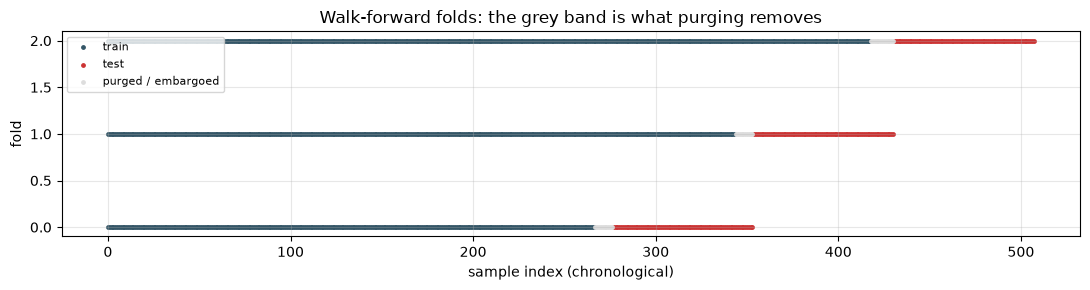

In [7]:
fig, ax = plt.subplots(figsize=(11, 3))
for fold, (train_idx, test_idx) in enumerate(splitter.split(data.spans)):
    ax.scatter(train_idx, [fold] * len(train_idx), s=6, c="#356",
               label="train" if fold == 0 else None)
    ax.scatter(test_idx, [fold] * len(test_idx), s=6, c="#c33",
               label="test" if fold == 0 else None)
    gap = np.setdiff1d(np.arange(0, test_idx[0]), train_idx)
    ax.scatter(gap, [fold] * len(gap), s=6, c="#ddd",
               label="purged / embargoed" if fold == 0 else None)
ax.set_xlabel("sample index (chronological)"); ax.set_ylabel("fold")
ax.set_title("Walk-forward folds: the grey band is what purging removes")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

## 4. Baselines first

An LSTM is only worth its complexity if it beats a bagged tree on the same features,
labels and splits. Running the baselines first sets the bar — and often clears the
whole question in one cell.

The forest uses AFML's guards for financial data: `max_features=1` and a minimum leaf
weight, because a deep unconstrained forest on correlated features and overlapping
samples memorises rather than generalises.

In [8]:
results = {}

results["logistic"] = pipeline.evaluate(
    data, make_model=lambda: logistic(seed=SEED), splitter=splitter
).fold_metrics.copy()
print("logistic done")

results["random_forest"] = pipeline.evaluate(
    data, make_model=lambda: random_forest(seed=SEED), splitter=splitter
).fold_metrics.copy()
print("random_forest done")

results["random_forest_full_window"] = pipeline.evaluate(
    data, make_model=lambda: random_forest(seed=SEED, last_only=False), splitter=splitter
).fold_metrics.copy()
print("random_forest_full_window done")

2026-08-22 13:26:12 | WARNING | afml_india.models.evaluate | Split 0 of 4 has only 190 training samples after purge; skipping (it will not appear in the fold results)


2026-08-22 13:26:12 | WARNING | afml_india.models.evaluate | Split 0 of 4 has only 190 training samples after purge; skipping (it will not appear in the fold results)


logistic done


2026-08-22 13:26:16 | WARNING | afml_india.models.evaluate | Split 0 of 4 has only 190 training samples after purge; skipping (it will not appear in the fold results)


random_forest done


random_forest_full_window done


## 5. The LSTM

Same folds, same weights. Two details that are easy to get wrong and are handled
inside the wrapper:

- **Sample weights enter the loss.** AFML uniqueness weights only matter if the
  optimiser sees them; passing them to `fit` is what makes overlapping labels count
  for less.
- **Early stopping is chronological.** The holdout is the tail of the training fold,
  not a random split — a random one lets a neighbouring overlapping sample leak in.

Scaling is refit on each training fold by `walk_forward_evaluate`, so no test-period
statistics reach training.

In [9]:
lstm_config = LSTMConfig(
    hidden_size=32, num_layers=2, dropout=0.25,
    learning_rate=1e-3, max_epochs=60, patience=10,
    batch_size=64, seed=SEED, device="cpu",
)

results["lstm"] = pipeline.evaluate(
    data, make_model=lambda: LSTMClassifier(lstm_config), splitter=splitter
).fold_metrics.copy()
print("lstm done")

2026-08-22 13:26:20 | WARNING | afml_india.models.evaluate | Split 0 of 4 has only 190 training samples after purge; skipping (it will not appear in the fold results)


lstm done


In [10]:
comparison = pd.DataFrame({
    name: summarise_folds(folds)[
        ["accuracy_mean", "accuracy_std", "roc_auc_mean", "roc_auc_std",
         "precision_mean", "recall_mean", "f1_mean", "log_loss_mean"]
    ]
    for name, folds in results.items()
}).T
comparison.round(4)

,accuracy_mean,accuracy_std,roc_auc_mean,roc_auc_std,precision_mean,recall_mean,f1_mean,log_loss_mean
logistic,0.5356,0.0511,0.6036,0.0518,0.6479,0.3958,0.4170,0.6932
random_forest,0.5146,0.0831,0.5747,0.0937,0.5209,0.4536,0.4640,0.6786
random_forest_full_window,0.4941,0.0855,0.5622,0.1117,0.4652,0.4282,0.4272,0.6771
lstm,0.5341,0.0584,0.5637,0.0441,0.5314,0.4601,0.4534,0.7576


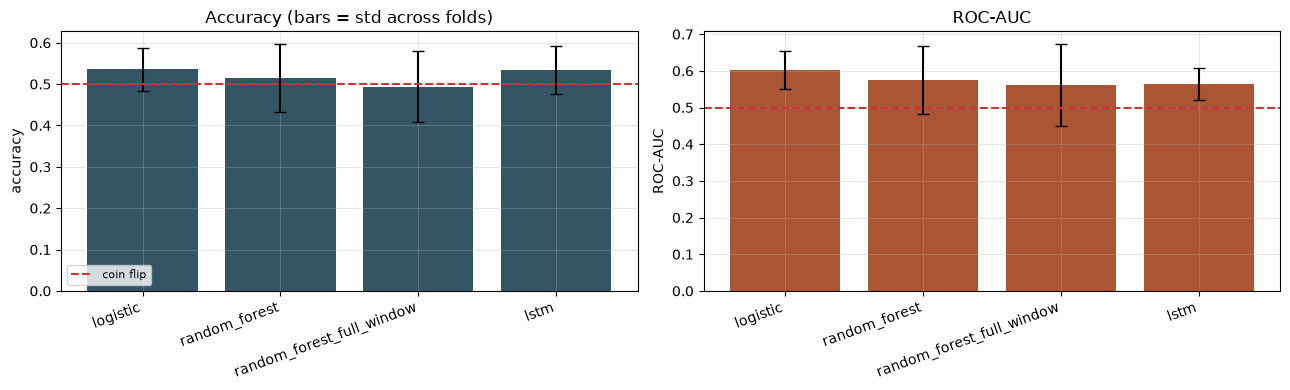

In [11]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
names = list(results)
x = np.arange(len(names))

acc = [results[n]["accuracy"].mean() for n in names]
acc_err = [results[n]["accuracy"].std() for n in names]
a1.bar(x, acc, yerr=acc_err, capsize=4, color="#356")
a1.axhline(0.5, c="#c33", ls="--", lw=1.5, label="coin flip")
a1.set_xticks(x); a1.set_xticklabels(names, rotation=20, ha="right")
a1.set_ylabel("accuracy"); a1.set_title("Accuracy (bars = std across folds)"); a1.legend(fontsize=8)

auc = [results[n]["roc_auc"].mean() for n in names]
auc_err = [results[n]["roc_auc"].std() for n in names]
a2.bar(x, auc, yerr=auc_err, capsize=4, color="#a53")
a2.axhline(0.5, c="#c33", ls="--", lw=1.5)
a2.set_xticks(x); a2.set_xticklabels(names, rotation=20, ha="right")
a2.set_ylabel("ROC-AUC"); a2.set_title("ROC-AUC")
plt.tight_layout(); plt.show()

In [12]:
print("Fold-by-fold accuracy — read the spread, not the mean:")
spread = pd.DataFrame({name: folds["accuracy"] for name, folds in results.items()})
print(spread.round(3).to_string())
print()
for name in results:
    lo, hi = spread[name].min(), spread[name].max()
    print(f"{name:>26}: mean {spread[name].mean():.3f}, range {lo:.3f}-{hi:.3f}")
print()
print("A model averaging above 0.5 with a fold range straddling it has not learned")
print("anything stable. On this data every arm should look like that.")

Fold-by-fold accuracy — read the spread, not the mean:
      logistic  random_forest  random_forest_full_window   lstm
fold                                                           
0        0.570          0.594                      0.593  0.597
1        0.477          0.428                      0.440  0.481
2        0.560          0.522                      0.450  0.524

                  logistic: mean 0.536, range 0.477-0.570
             random_forest: mean 0.515, range 0.428-0.594
 random_forest_full_window: mean 0.494, range 0.440-0.593
                      lstm: mean 0.534, range 0.481-0.597

A model averaging above 0.5 with a fold range straddling it has not learned
anything stable. On this data every arm should look like that.


## 6. Does fractional differencing change the classification result?

The same question notebook 03 asked of forecasting, asked of classification. Rebuild
the dataset with `d = 1.0` (plain returns) and with no fracdiff block at all, and rerun
the identical model on the identical splits.

In [13]:
# Four arms. Note d=0.0 is NOT "no differencing" — it is the identity filter, so it
# feeds the raw non-stationary log level in as a feature. That arm is included
# deliberately, because it shows what stationarity is actually buying.
arms = {
    "fracdiff (min d)": config,
    "returns (d=1.0)": PipelineConfig(**{**config.__dict__, "fracdiff_d": 1.0}),
    "raw log level (d=0.0)": PipelineConfig(**{**config.__dict__, "fracdiff_d": 0.0}),
    "no fracdiff features": PipelineConfig(
        **{**config.__dict__, "include_fracdiff": False}
    ),
}

arm_results = {}
for name, arm_config in arms.items():
    arm_pipeline = TickerPipeline(arm_config)
    try:
        arm_data = arm_pipeline.prepare(symbol, snapshot=snap)
        scored = arm_pipeline.evaluate(
            arm_data, make_model=lambda: random_forest(seed=SEED), splitter=splitter
        )
        arm_results[name] = {
            "d": arm_data.d,
            "n_features": arm_data.X.shape[-1],
            "n_samples": len(arm_data.X),
            **summarise_folds(scored.fold_metrics)[
                ["accuracy_mean", "accuracy_std", "roc_auc_mean", "roc_auc_std"]
            ].to_dict(),
        }
        print(f"{name}: done")
    except Exception as exc:
        print(f"{name}: {exc}")

table = pd.DataFrame(arm_results).T.round(4)
print(table.to_string())
print()
print("If the d=0.0 arm scores best, treat that as a warning rather than a result:")
print("a non-stationary level feature lets a tree split on 'which part of the sample")
print("is this', which is trend memorisation, not prediction. It is exactly the")
print("failure fractional differencing exists to avoid.")

2026-08-22 13:26:35 | WARNING | afml_india.models.evaluate | Split 0 of 4 has only 190 training samples after purge; skipping (it will not appear in the fold results)


fracdiff (min d): done


2026-08-22 13:26:50 | WARNING | afml_india.models.evaluate | Split 0 of 4 has only 188 training samples after purge; skipping (it will not appear in the fold results)


returns (d=1.0): done


2026-08-22 13:27:04 | WARNING | afml_india.models.evaluate | Split 0 of 4 has only 188 training samples after purge; skipping (it will not appear in the fold results)


raw log level (d=0.0): done


2026-08-22 13:27:18 | WARNING | afml_india.models.evaluate | Split 0 of 4 has only 188 training samples after purge; skipping (it will not appear in the fold results)


no fracdiff features: done
                         d  n_features  n_samples  accuracy_mean  accuracy_std  roc_auc_mean  roc_auc_std
fracdiff (min d)       0.1        30.0      508.0         0.5146        0.0831        0.5747       0.0937
returns (d=1.0)        1.0        30.0      601.0         0.5365        0.0666        0.5709       0.0578
raw log level (d=0.0)  0.0        30.0      601.0         0.5448        0.0418        0.6152       0.0148
no fracdiff features   NaN        28.0      601.0         0.5503        0.0577        0.5644       0.0433

If the d=0.0 arm scores best, treat that as a warning rather than a result:
a non-stationary level feature lets a tree split on 'which part of the sample
is this', which is trend memorisation, not prediction. It is exactly the
failure fractional differencing exists to avoid.


## 7. Sweep the point-in-time universe

The step that separates a result from an artefact. `run_universe` applies the identical
configuration to every member and returns one row per ticker; a ticker that fails — too
few bars, no events, degenerate labels — is logged and skipped rather than aborting.

Read the **cross-section**. With five names and four folds each, one will look good by
chance; with fifty, several will. The question is whether the distribution as a whole
sits above 0.5, not whether its maximum does.

In [14]:
universe_table, universe_results = run_universe(
    snap, make_model=lambda: random_forest(seed=SEED), config=config,
)
universe_table.round(4)

2026-08-22 13:27:32 | WARNING | afml_india.models.evaluate | Split 0 of 4 has only 190 training samples after purge; skipping (it will not appear in the fold results)


2026-08-22 13:27:46 | WARNING | afml_india.models.evaluate | Split 0 of 4 has only 190 training samples after purge; skipping (it will not appear in the fold results)


2026-08-22 13:28:00 | WARNING | afml_india.models.evaluate | Split 0 of 4 has only 191 training samples after purge; skipping (it will not appear in the fold results)


2026-08-22 13:28:14 | WARNING | afml_india.models.evaluate | Split 0 of 4 has only 190 training samples after purge; skipping (it will not appear in the fold results)


2026-08-22 13:28:28 | WARNING | afml_india.models.evaluate | Split 0 of 4 has only 191 training samples after purge; skipping (it will not appear in the fold results)


,n_bars,n_events,n_labels,n_samples,n_features,d,label_balance,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,avg_precision_mean,avg_precision_std,log_loss_mean,log_loss_std,positive_rate_mean,positive_rate_std,base_rate_mean,base_rate_std,n_train_mean,n_train_std,n_test_mean,n_test_std,n_folds
ticker,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
HDFCB_IN,3207,663,638,548,30,0.2,0.4069,0.4330,0.0684,0.3941,0.0513,0.7507,0.2159,0.5089,0.0562,0.5692,0.0796,0.5023,0.0415,0.7327,0.0472,0.7625,0.1722,0.3410,0.0239,364.0000,87.0000,87.0000,0.0000,3.0
ICICIBC_IN,3212,653,608,508,30,0.1,0.5059,0.5146,0.0831,0.5209,0.0828,0.4536,0.2255,0.4640,0.1691,0.5747,0.0937,0.6110,0.0856,0.6786,0.0262,0.4199,0.2295,0.4892,0.0750,343.0000,75.5050,77.0000,0.0000,3.0
INFO_IN,3208,613,584,472,30,0.2,0.5445,0.5798,0.1549,0.6524,0.1149,0.4812,0.2621,0.5049,0.1788,0.7076,0.1688,0.6724,0.1603,0.6643,0.0350,0.3725,0.1704,0.4657,0.1358,326.3333,68.5006,68.0000,0.0000,3.0
RIL_IN,3207,634,573,497,30,0.1,0.5010,0.5413,0.0652,0.5193,0.0850,0.7121,0.2577,0.5905,0.1167,0.5094,0.1029,0.5446,0.1095,0.7127,0.0432,0.6847,0.2849,0.5244,0.0687,337.6667,75.0089,74.3333,0.5774,3.0
TCS_IN,3207,608,577,498,30,0.3,0.6104,0.3970,0.0741,0.5295,0.1428,0.3502,0.4798,0.2913,0.2973,0.4364,0.0250,0.5877,0.0823,0.7363,0.0130,0.3649,0.4930,0.6431,0.1328,338.6667,76.0088,74.6667,0.5774,3.0


In [15]:
scored = universe_table.dropna(subset=["accuracy_mean"]) if "accuracy_mean" in universe_table else pd.DataFrame()

if scored.empty:
    print("No ticker produced a scored result — check the errors column above.")
else:
    print(f"Scored {len(scored)} of {len(universe_table)} tickers\n")
    print(f"Mean accuracy across the cross-section : {scored['accuracy_mean'].mean():.4f}")
    print(f"Std  across tickers                    : {scored['accuracy_mean'].std():.4f}")
    print(f"Tickers above 0.5                      : {(scored['accuracy_mean'] > 0.5).sum()} of {len(scored)}")
    print(f"Mean ROC-AUC                           : {scored['roc_auc_mean'].mean():.4f}")
    print()
    print("Selected differencing order by ticker:")
    print(scored["d"].round(3).to_string())

Scored 5 of 5 tickers

Mean accuracy across the cross-section : 0.4931
Std  across tickers                    : 0.0761
Tickers above 0.5                      : 3 of 5
Mean ROC-AUC                           : 0.5594

Selected differencing order by ticker:
ticker
HDFCB_IN      0.2
ICICIBC_IN    0.1
INFO_IN       0.2
RIL_IN        0.1
TCS_IN        0.3


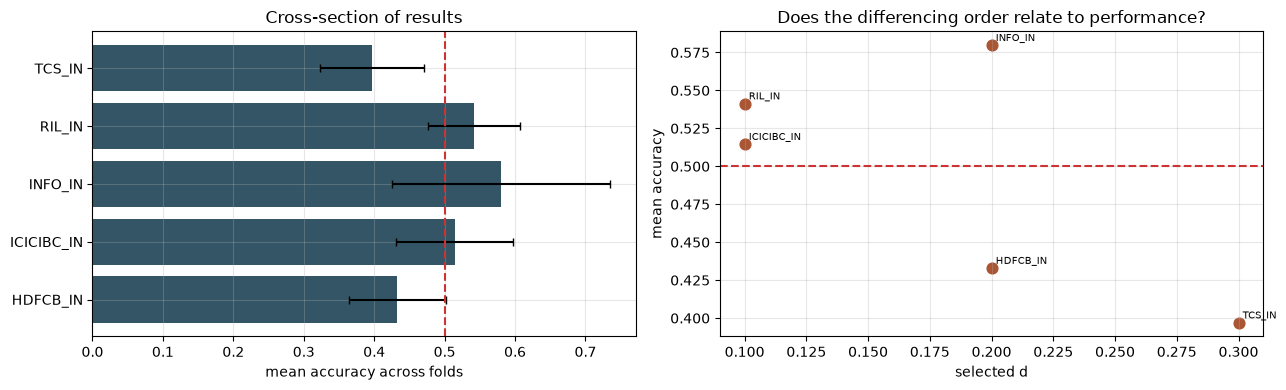

In [16]:
if not scored.empty and len(scored) > 1:
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
    a1.barh(scored.index, scored["accuracy_mean"],
            xerr=scored.get("accuracy_std"), capsize=3, color="#356")
    a1.axvline(0.5, c="#c33", ls="--", lw=1.5)
    a1.set_xlabel("mean accuracy across folds"); a1.set_title("Cross-section of results")

    a2.scatter(scored["d"], scored["accuracy_mean"], s=60, color="#a53")
    for ticker, row in scored.iterrows():
        a2.annotate(ticker, (row["d"], row["accuracy_mean"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")
    a2.axhline(0.5, c="#c33", ls="--", lw=1.5)
    a2.set_xlabel("selected d"); a2.set_ylabel("mean accuracy")
    a2.set_title("Does the differencing order relate to performance?")
    plt.tight_layout(); plt.show()

## 8. From probability to position

A classifier output is not a trade. AFML's bet sizing maps the probability to a
position size, and the Indian cost stack decides whether that position is worth
taking at all.

The cell below reports the round trip as a multiple of one bar's return sigma. Read
that ratio, do not assume it: it depends entirely on how volatile a bar is, which in
turn depends on the bar threshold. On this synthetic tape bar sigma is implausibly
large, so the ratio looks comfortable. On real NSE data a rupee bar at 50 bars a day
typically has a sigma in the tens of basis points, at which point a 23 bps delivery
round trip is the same order as the move being predicted — and a signal acting every
bar cannot pay for itself.

In [17]:
from afml_india.data.costs import CostModel, Segment

best_arm = max(results, key=lambda k: results[k]["accuracy"].mean())
scored_model = pipeline.evaluate(
    data,
    make_model=(lambda: LSTMClassifier(lstm_config)) if best_arm == "lstm"
    else (lambda: random_forest(seed=SEED)),
    splitter=splitter,
)
predictions = scored_model.predictions

# AFML bet sizing: size on the model's confidence above the 0.5 decision boundary.
edge = (predictions["proba"] - 0.5).abs() * 2.0
side = np.where(predictions["proba"] >= 0.5, 1, -1)
positions = pd.Series(side * edge, index=predictions.index, name="position")

bar_sigma_bps = float(np.log(data.bars["close"]).diff().std() * 1e4)
for segment in (Segment.INTRADAY, Segment.DELIVERY):
    rt = CostModel(segment=segment).round_trip_bps(
        price=float(data.bars["close"].iloc[-1]), quantity=1000
    )
    print(f"{segment.value:>9} round trip: {rt:6.2f} bps  "
          f"= {rt / bar_sigma_bps:5.2f}x one bar's sigma ({bar_sigma_bps:.1f} bps)")

turnover = positions.diff().abs().sum()
print(f"\nSum of position changes over {len(positions)} signals: {turnover:.1f}")
print("Multiply that by the round-trip cost to see the hurdle before any edge counts.")

2026-08-22 13:28:32 | WARNING | afml_india.models.evaluate | Split 0 of 4 has only 190 training samples after purge; skipping (it will not appear in the fold results)


 intraday round trip:   4.52 bps  =  0.05x one bar's sigma (84.1 bps)
 delivery round trip:  23.22 bps  =  0.28x one bar's sigma (84.1 bps)

Sum of position changes over 231 signals: 19.6
Multiply that by the round-trip cost to see the hurdle before any edge counts.


## Takeaways

1. **Classification with triple-barrier labels asks the right question.** Sign of the
   move over a defined holding period given a defined stop — not the level.

2. **Purging is mandatory but cheap; overlap is expensive.** Purging removes only the
   boundary samples whose labels resolve inside the test window — a few percent here —
   and a score computed without it is inflated by leakage. The larger cost is the
   collapse in effective sample size: at 1:1 barriers the mean uniqueness on this
   ticker is around 0.27, so the model has roughly a quarter of the independent
   observations its row count suggests.

3. **Run the baselines first.** If a bagged tree on the event bar matches the LSTM on
   the same folds, the sequence model is buying nothing.

4. **Read the spread across folds and across tickers.** A mean above 0.5 with a range
   straddling it is noise. The cross-section is the evidence, not the best name.

5. **Check costs against bar sigma before believing any accuracy number.** The
   round trip is fixed; what varies is how large a bar's move is. Compute the ratio
   for your own bars — when it approaches 1, a classifier at 55% on 1:1 barriers
   cannot pay for itself, and the fix is bet sizing and a longer holding period
   rather than a better model.

### Where to take it

- Rerun everything on real Bloomberg data; every number here is synthetic.
- **Meta-labelling** (AFML ch. 3): keep a simple primary model for side, and train the
  ML layer only to decide *whether to act*. This usually helps far more than a better
  primary model.
- Widen the universe and lengthen the tick window.
- Add feature importance (MDI, MDA, SFI from fin-kit) to prune the 30 features down to
  the ones that survive purged evaluation.